# CÍL 3: Matplotlib

> Tento notebook je součástí cvičení 9 předmětu BPC-PRG.  
> Projdi ho postupně – každou buňku spusť klávesou **Shift+Enter**.  
> 📥 **[Stáhnout notebook](cviceni_09_matplotlib.ipynb)** &nbsp;|&nbsp; 📥 **[Stáhnout data (mpl_data.npz)](mpl_data.npz)**


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Všechna data jsou předpřipravena – stáhni mpl_data.npz a načti:
d = np.load("mpl_data.npz")

t, ekg, resp        = d["t"], d["ekg"], d["resp"]
mri                 = d["mri"]
zatez               = [d["klid"], d["chuze"], d["beh"], d["sprint"]]
zdravi, diabetici   = d["zdravi"], d["diabetici"]

# Zátěžový test: tf_test.shape == (30, 60)
# 30 pacientů měřených každou minutu po dobu 60 minut
# Fáze:  Klid 0–9 min | Zahřívání 10–19 | Aerobní 20–39 | Sprint 40–49 | Regenerace 50–59
tf_test = d["tf_test"]


## Co je Matplotlib?

[**Matplotlib**](https://matplotlib.org/) je nejrozšířenější Python knihovna pro tvorbu grafů a vizualizací. Vznikla v roce 2003 jako náhrada za grafiku MATLABu – odtud jméno.

Její hlavní modul, který budeš téměř vždy importovat, se jmenuje **`pyplot`**. Poskytuje rozhraní inspirované MATLABem a umožňuje tvorbu grafů několika řádky kódu.

V biomedicíně ji využiješ na:

- vykreslení **časových řad** (EKG, dech, krevní tlak, teplota),
- zobrazení **medicínských snímků** (MRI, CT, histologické řezy) jako 2D matice,
- **statistické grafy** – boxploty pro srovnání skupin pacientů, histogramy pro rozložení hodnot,
- **vědecké publikace** – výstup ve formátu PDF/SVG s přesnou kontrolou nad každým detailem.

Matplotlib je úzce provázaný s NumPy – jako data přijímají funkce přímo numpy pole.

### Co vše lze vykreslit?

| Typ grafu | Funkce | Kdy ho použít |
|-----------|--------|---------------|
| Spojnicový | `ax.plot()` | Časové řady – EKG, dech, průběh léčby |
| Sloupcový | `ax.bar()` | Srovnání kategorií – průměry skupin, výsledky měření |
| Bodový (scatter) | `ax.scatter()` | Korelace dvou proměnných – výška vs. váha |
| Histogram | `ax.hist()` | Rozložení hodnot – glykémie, BMI, TF |
| Boxplot | `ax.boxplot()` | Mediány a rozptyl napříč skupinami pacientů |
| Obrázek / heatmapa | `ax.imshow()` | MRI, CT snímky, korelační matice |
| Výsečový | `ax.pie()` | Podíly – zastoupení diagnóz v populaci |

> **💡 Poznámka:** Pro interaktivní a webové grafy existují moderní alternativy jako **Plotly** nebo **Bokeh**. Matplotlib je ale základ, na kterém jsou postavené i vyšší knihovny jako **Seaborn** nebo **Pandas** `.plot()`.

## 3.1 Základní struktura matplotlib

Matplotlib má dvě vrstvy rozhraní:

- **`plt.plot()`** – rychlé globální funkce, dobré pro jeden jednoduchý graf,
- **`fig, ax = plt.subplots()`** – přímá práce s objekty Figure a Axes, doporučovaný přístup jakmile máš víc grafů nebo potřebuješ přesnou kontrolu.

Budeme používat druhý přístup – je přehlednější a lépe se škáluje na složitější vizualizace.

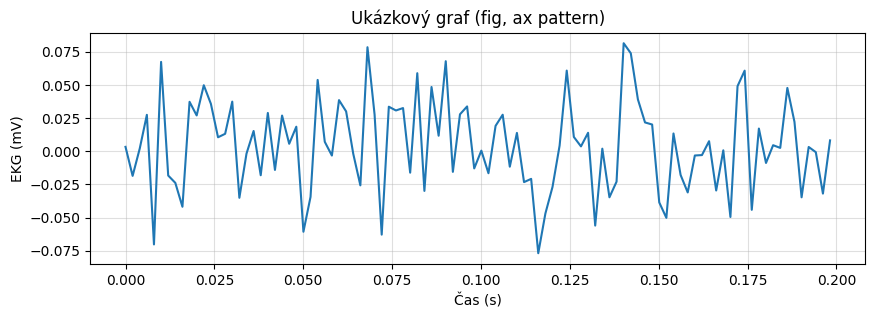

In [2]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t[:100], ekg[:100])
ax.set_title("Ukázkový graf (fig, ax pattern)")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.4)
plt.show()


## 3.2 Vykreslení signálu

Spojnicový graf je základní vizualizace pro časové řady – EKG, dech, krevní tlak, teplotu.

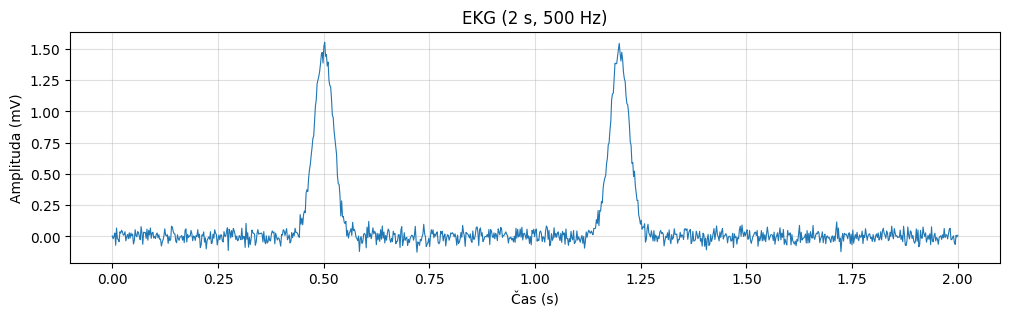

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.set_title("EKG (2 s, 500 Hz)")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.grid(True, alpha=0.4)
plt.show()


### Více grafů pod sebou – `sharex=True`

`plt.subplots(2, 1, sharex=True)` vytvoří dva grafy sdílející osu X – ideální pro srovnání více kanálů (EKG + dech, EKG + tlak apod.).

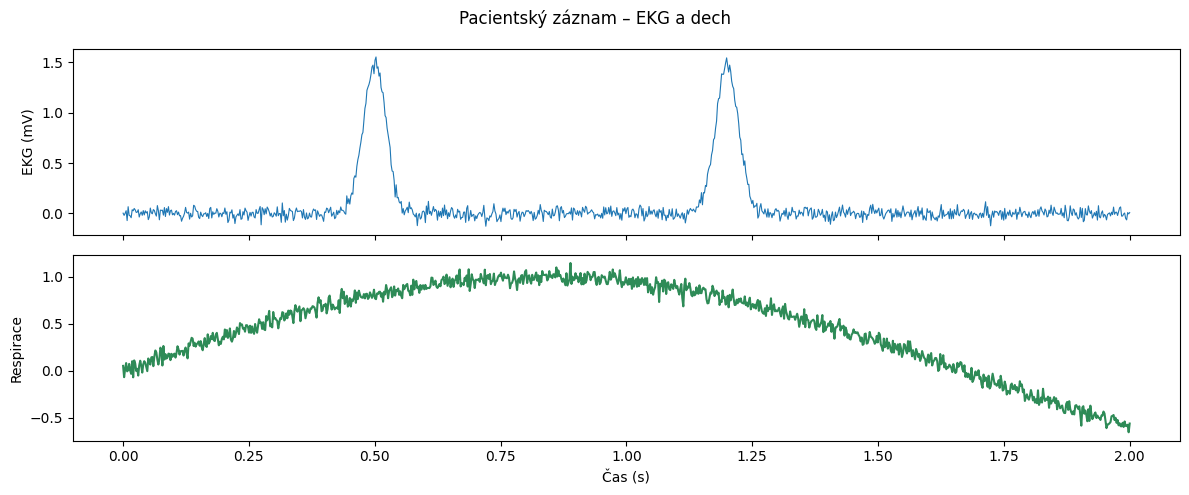

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t, ekg, linewidth=0.8)
ax1.set_ylabel("EKG (mV)")
ax2.plot(t, resp, color="seagreen")
ax2.set_ylabel("Respirace")
ax2.set_xlabel("Čas (s)")
fig.suptitle("Pacientský záznam – EKG a dech")
plt.tight_layout()
plt.show()


### Detekce událostí – `ax.scatter()`

Při analýze signálů nás často zajímá, kdy nastane konkrétní událost – R-vlna v EKG, vrchol respirace, nástup záchvatu. Události lze detekovat naprahováním a vizualizovat jako body přes spojnicový graf pomocí `ax.scatter()`.

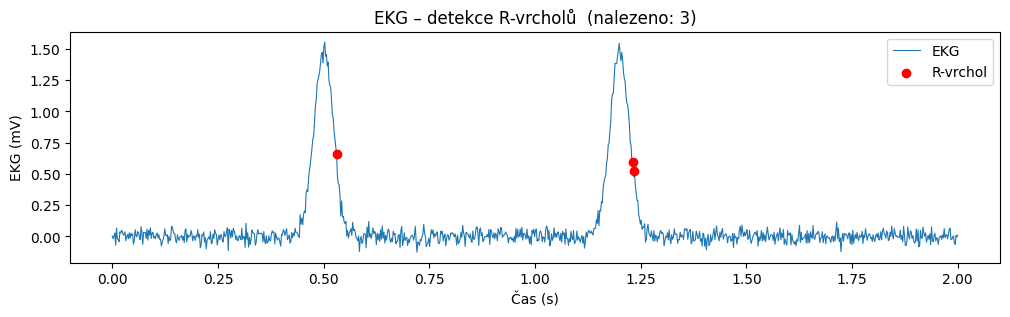

In [5]:
# Prahování: vzorky nad prahem → True
prahovana = ekg > 0.5
# Zachovej jen poslední True v každé sérii (= vrchol vlny)
r_peaks = prahovana & ~np.roll(prahovana, -1)
r_peaks[-1] = False

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8, label="EKG")
ax.scatter(t[r_peaks], ekg[r_peaks], color="red", zorder=5, label="R-vrchol")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.set_title(f"EKG – detekce R-vrcholů  (nalezeno: {r_peaks.sum()})")
ax.legend()
plt.show()


## 3.3 Zobrazení matice / obrazu

`imshow()` zobrazí 2D numpy pole jako obrázek nebo heatmapu – každá hodnota odpovídá barvě pixelu. Hodí se pro medicínské snímky (MRI, CT), korelační matice nebo síťové váhy v neuronových sítích.

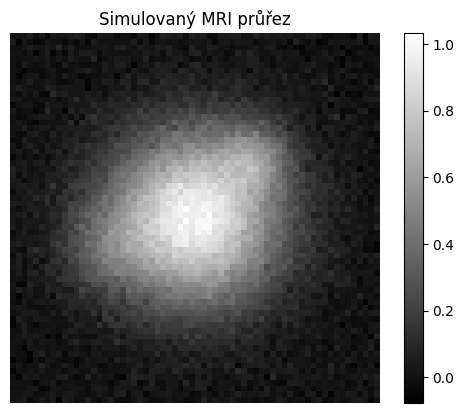

In [6]:
fig, ax = plt.subplots()
im = ax.imshow(mri, cmap="gray")
fig.colorbar(im)
ax.axis("off")
ax.set_title("Simulovaný MRI průřez")
plt.show()


> **💡 Tip:** Pro medicínské obrazy se nejčastěji používá `cmap="gray"`. `viridis` je dobrou volbou pro vědecké heatmapy – je perceptuálně uniformní (stejné rozdíly v datech odpovídají stejně vnímaným rozdílům v barvě) a čitelná i při výtisku nebo pro barvoslepé.

## 3.3b Segmentace obrazu – prahování

V medicínské analýze obrazu nás zajímá, *kde* v obraze se nachází určitá struktura –
cévy, tumor, tuková tkáň. Základní přístup je **prahování** (*thresholding*):
vytvoříme **binární masku** – numpy pole `bool`, kde `True` označuje pixely patřící
hledané struktuře.

```python
maska = obraz > PRÁH      # pixely nad prahem → True
```

Masku pak zobrazíme vedle původního obrazu pomocí `plt.subplots(1, 2)`.


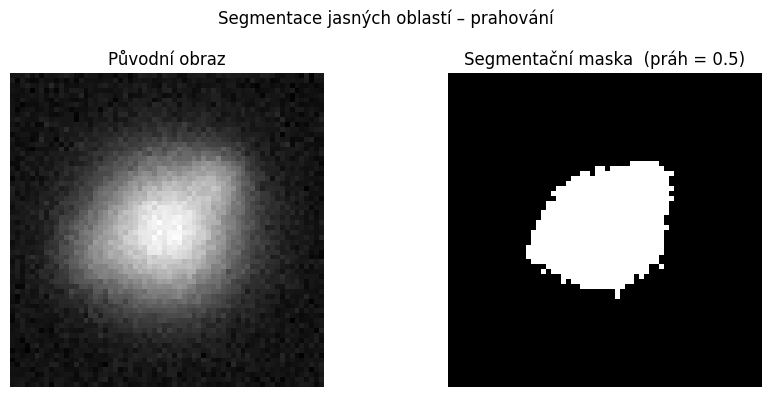

Plocha jasných oblastí: 14.1 %  |  Průměrná intenzita: 0.720


In [7]:
PRAH = 0.5
maska = mri > PRAH

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax1.imshow(mri, cmap="gray")
ax1.set_title("Původní obraz")
ax1.axis("off")
ax2.imshow(maska, cmap="gray")
ax2.set_title(f"Segmentační maska  (práh = {PRAH})")
ax2.axis("off")
plt.suptitle("Segmentace jasných oblastí – prahování")
plt.tight_layout()
plt.show()

podil = maska.sum() / maska.size * 100
print(f"Plocha jasných oblastí: {podil:.1f} %  |  Průměrná intenzita: {mri[maska].mean():.3f}")


## 3.4 Boxplot – statistické srovnání skupin

Boxplot je ideální pro srovnání rozložení hodnot napříč skupinami – různé pacienty, různé podmínky měření, různé diagnózy. Ukazuje medián, kvartily, vousy a odlehlé hodnoty.

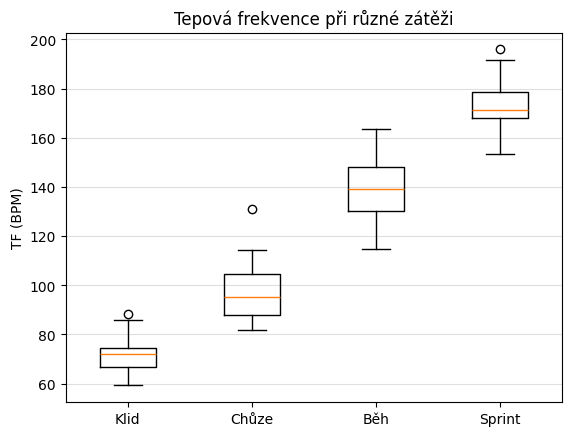

In [8]:
fig, ax = plt.subplots()
ax.boxplot(zatez, tick_labels=["Klid", "Chůze", "Běh", "Sprint"])
ax.set_title("Tepová frekvence při různé zátěži")
ax.set_ylabel("TF (BPM)")
ax.grid(True, axis="y", alpha=0.4)
plt.show()


## 3.5 Histogram – rozložení hodnot

Histogram ukazuje, jak jsou hodnoty rozloženy. Hodí se pro první pohled na data – je rozložení symetrické? Má odlehlé hodnoty? Odpovídá normálnímu rozložení?

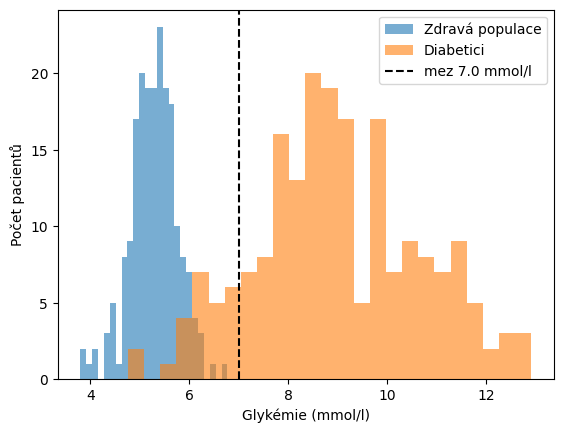

In [9]:
fig, ax = plt.subplots()
ax.hist(zdravi,    bins=25, alpha=0.6, label="Zdravá populace")
ax.hist(diabetici, bins=25, alpha=0.6, label="Diabetici")
ax.axvline(7.0, color="black", linestyle="--", label="mez 7.0 mmol/l")
ax.set_xlabel("Glykémie (mmol/l)")
ax.set_ylabel("Počet pacientů")
ax.legend()
plt.show()


## 3.6 Segmentace signálu – `axvspan`

V biomedicíně je signál często rozdělen do fází: klidová, zátěžová, regenerační.  
`ax.axvspan(x_start, x_end, alpha=..., color=..., label=...)` zakreslí barevný pás
do pozadí grafu – tím vizuálně „segmentuje" průběh signálu bez přepisování dat.


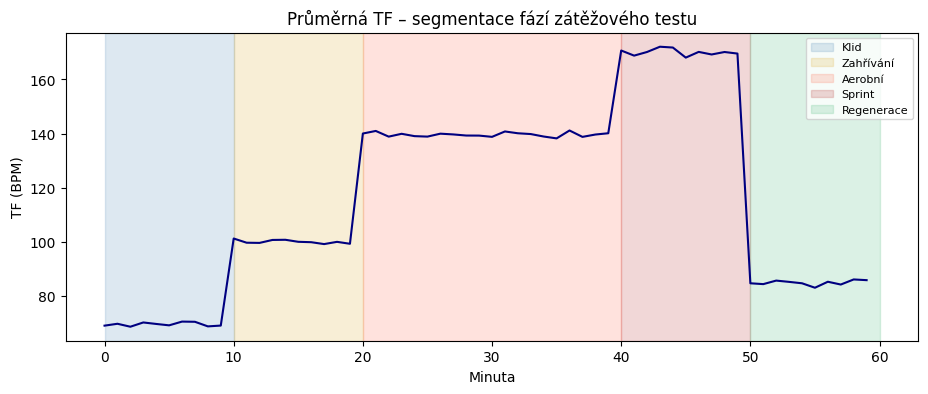

In [10]:
fazes = [(0,  10, "steelblue",       "Klid"),
         (10, 20, "goldenrod",       "Zahřívání"),
         (20, 40, "tomato",          "Aerobní"),
         (40, 50, "firebrick",       "Sprint"),
         (50, 60, "mediumseagreen",  "Regenerace")]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tf_test.mean(axis=0), color="navy", linewidth=1.5)
for x0, x1, col, label in fazes:
    ax.axvspan(x0, x1, alpha=0.18, color=col, label=label)
ax.set_xlabel("Minuta")
ax.set_ylabel("TF (BPM)")
ax.set_title("Průměrná TF – segmentace fází zátěžového testu")
ax.legend(loc="upper right", fontsize=8)
plt.show()


---

## 📝 ÚKOL: Zátěžový test – analýza a vizualizace

Data `tf_test` jsou již načtena v nastavovací buňce.  
Jde o matici **30 pacientů × 60 minut** tepové frekvence (BPM) z protokolu:

| Fáze | Minuty |
|------|--------|
| Klid | 0–9 |
| Zahřívání | 10–19 |
| Aerobní | 20–39 |
| Sprint | 40–49 |
| Regenerace | 50–59 |

**1. Průměrný signál v čase**  
Vypočítej průměrnou TF napříč pacienty pro každou minutu (`mean(axis=0)`) a vykresli jako spojnicový graf.  
Osa X = minuty (0–59), osa Y = TF (BPM). Přidej nadpis a popsané osy.

**2. Segmentace fází**  
Do grafu z úkolu 1 přidej barevné pozadí pro každou fázi pomocí `ax.axvspan()`.  
Každá fáze musí mít vlastní barvu a popisek v legendě (viz ukázka výše).

**3. Boxplot per fáze**  
Pro každou fázi vezmi hodnoty všech pacientů a všech minut (`tf_test[:, 0:10].ravel()` atd.) a vykresli boxplot pěti skupin.  
Popisky: `["Klid", "Zahřívání", "Aerobní", "Sprint", "Regenerace"]`.

**4. Histogram – klid vs. sprint**  
Do jednoho histogramu vykresli hodnoty fáze Klid a fáze Sprint (oba `ravel()`).  
Přidej legendu a popsané osy.

**5. Segmentace snímku**  
`mri` máš již načtený z `mpl_data.npz`.  
Vytvoř binární masku prahováním: `maska = mri > PRÁH` (zkus práh 0.5).  
Zobraz vedle sebe původní obraz a masku pomocí `plt.subplots(1, 2)` + `imshow()`.  
Vypiš, kolik procent plochy tvoří pixely nad prahem a jaká je jejich průměrná intenzita.

**6.** Ke každému grafu přidej markdownovou buňku s jednou větou – co graf ukazuje.


In [11]:
# --- ZDE PIŠE STUDENT ---

# tf_test.shape == (30, 60)
# Fáze: Klid 0–9, Zahřívání 10–19, Aerobní 20–39, Sprint 40–49, Regenerace 50–59

# 1. Průměrná TF v čase (signál)


# 2. Segmentace fází (axvspan) – přidej do grafu výše


# 3. Boxplot – 5 fází
faze_data   = [tf_test[:, 0:10].ravel(), tf_test[:, 10:20].ravel(),
               tf_test[:, 20:40].ravel(), tf_test[:, 40:50].ravel(),
               tf_test[:, 50:60].ravel()]
faze_labels = ["Klid", "Zahřívání", "Aerobní", "Sprint", "Regenerace"]


# 4. Histogram – klid vs. sprint


# 5. Segmentace snímku
# mri je 2D numpy pole (64×64) – pixely nad prahem → True
PRAH = 0.5


